<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-3?scriptVersionId=293478922" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [29]:
import torch  
from torchvision import datasets, transforms 

In [30]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [31]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [32]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [33]:
img, label = data_train[2000]

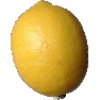

In [34]:
img

In [35]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [36]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [37]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [38]:
test_transform(img).shape

torch.Size([3, 64, 64])

In [39]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [40]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [41]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [42]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


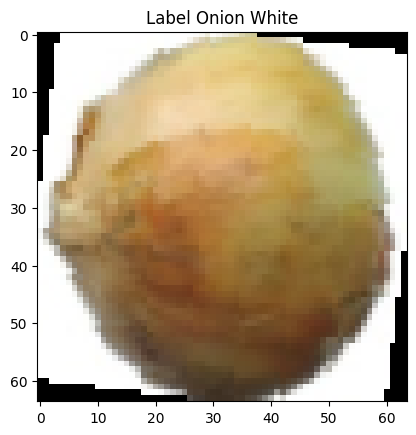

(64, 64, 3)


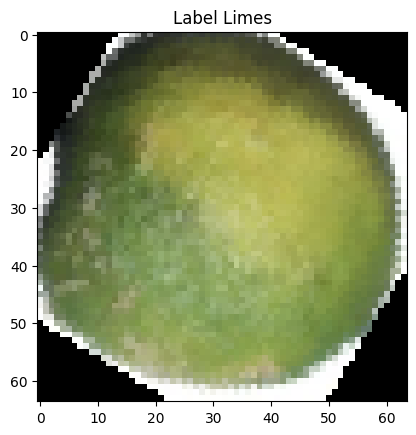

(64, 64, 3)


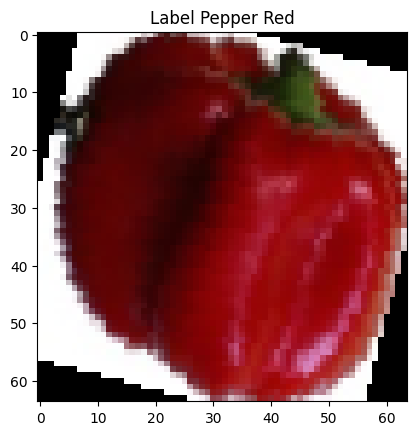

In [43]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

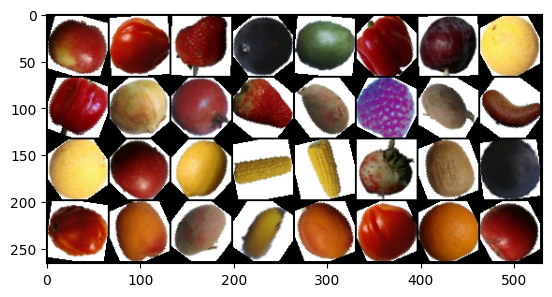

In [44]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [45]:
img, label = train_data[0]

img.shape

torch.Size([3, 64, 64])

In [46]:
3*64*64

12288

In [47]:
len(dataset.classes)

33

In [48]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
    nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
)


# підключення до процесора
device = 'cuda'
model = model.to(device)

In [49]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[-0.0524,  0.0119,  0.0906, -0.0434, -0.1813, -0.1117, -0.0967, -0.0200,
         -0.1213, -0.1089,  0.0334,  0.0352, -0.0791,  0.0934, -0.0448, -0.1058,
         -0.0799, -0.0623,  0.0243, -0.0388, -0.0682, -0.0716,  0.0878, -0.0154,
          0.0401,  0.0800,  0.1297,  0.1413, -0.0337, -0.1110, -0.1240,  0.0294,
         -0.0165]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [50]:
#ймовірності
probs = nn.Softmax()(result)
probs

tensor([[0.0294, 0.0313, 0.0339, 0.0296, 0.0258, 0.0277, 0.0281, 0.0303, 0.0274,
         0.0277, 0.0320, 0.0320, 0.0286, 0.0340, 0.0296, 0.0278, 0.0286, 0.0291,
         0.0317, 0.0298, 0.0289, 0.0288, 0.0338, 0.0305, 0.0322, 0.0335, 0.0352,
         0.0356, 0.0299, 0.0277, 0.0273, 0.0319, 0.0304]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [51]:
label

17

**# Визначення функції втрат та оптимізатора**

In [52]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.502060890197754
loss: 3.770507335662842
loss: 3.5732765197753906
loss: 3.477698802947998
loss: 3.4224014282226562
loss: 3.4278993606567383
loss: 3.3101859092712402
loss: 3.2900218963623047
loss: 3.238004207611084
loss: 3.2762367725372314
loss: 3.2247612476348877
loss: 3.132249593734741
loss: 3.0929994583129883
loss: 3.05800199508667
loss: 3.0418620109558105
loss: 2.974520683288574
loss: 2.939932346343994
loss: 2.847736358642578
loss: 2.802332878112793
loss: 2.815101146697998
loss: 2.760535717010498
loss: 2.5795981884002686
loss: 2.6605420112609863
loss: 2.5960311889648438
loss: 2.5192956924438477
loss: 2.5876801013946533
loss: 2.4918723106384277
loss: 2.404977321624756
loss: 2.329683303833008
loss: 2.2166428565979004
loss: 2.258301019668579
loss: 2.1600699424743652
loss: 2.0339879989624023
loss: 2.056161642074585
loss: 1.9791845083236694
loss: 1.9408199787139893
loss: 1.8848791122436523
loss: 1.8936398029327393
loss: 1.7263731956481934
loss: 1.671006202697754
loss: 1.7151228189

In [64]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(nn.Softmax()(prediction))

17
tensor([[1.1216e-05, 3.9790e-05, 6.7128e-14, 2.4574e-14, 2.0527e-04, 3.4080e-34,
         9.1705e-03, 9.9495e-07, 2.2254e-28, 1.2970e-09, 1.6077e-03, 3.3597e-08,
         6.0488e-18, 3.7438e-04, 3.2797e-03, 5.4922e-07, 6.9284e-19, 9.8468e-01,
         1.6969e-14, 5.9247e-07, 9.0387e-18, 3.8053e-05, 5.8667e-04, 1.1662e-20,
         4.7415e-15, 1.0461e-10, 5.0263e-16, 6.5544e-10, 1.2171e-11, 8.7313e-14,
         1.8640e-07, 1.2104e-18, 3.6687e-09]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


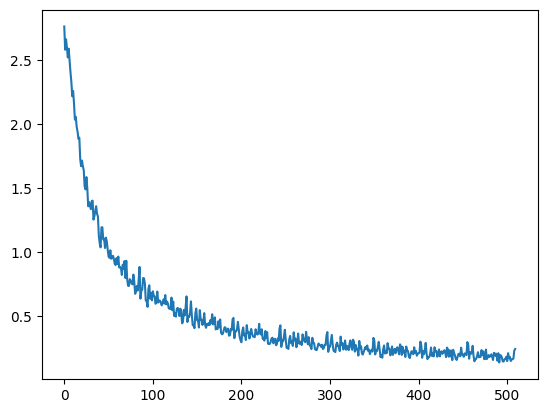

In [54]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

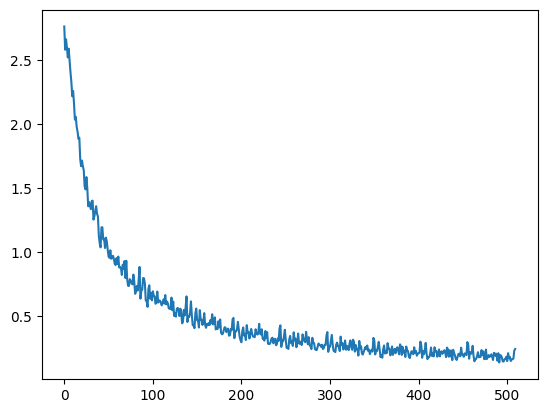

In [55]:
plt.plot(new_list)